<a href="https://colab.research.google.com/github/juancast-data-analyst/correlation-analysis-NovaRetail/blob/main/S8_Student_Version_Project_NovaRetail_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

In [ ]:
#Validación de valores min y max de columnas numéricas y binarias con describe
columnas_númericas_binarias = ['edad','nivel_ingreso','visitas_mes','compras_mes','gasto_publicidad_dirigida','satisfaccion','ingreso_anual','miembro_premium','abandono']
df[columnas_númericas_binarias].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual,miembro_premium,abandono
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180,0.139267,0.150733
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888,0.346236,0.357801
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000,0.000000,0.000000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000,0.000000,0.000000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000,1.000000,1.000000


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`
  

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` tiene tipo de dato float64 (con decimales) cambiar a tipo int64 ya que los valores son números enteros normalmente.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional. Para el Analisis se ignora la variable 'id_cliente' no aporta información relevante para el analisis.

In [ ]:
# Corregir el tipo de dato de la variable 'edad'
df['edad'] = df['edad'].astype(int)

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
columnas_numericas = ['edad','nivel_ingreso','visitas_mes','compras_mes','gasto_publicidad_dirigida','satisfaccion','ingreso_anual']
df[columnas_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


**Diagnóstico inicial de variables numéricas**

- `edad` - Rango 18–75 años. Desvío de ±11.5 años indica audiencia amplia y diversa, no segmentada por edad.
- `nivel_ingreso` - El rango va de 8k a 74.8k. Alta dispersión sugiere base de clientes heterogénea.
- `visitas_mes` - El mínimo es 1 visita (ningún usuario inactivo en la base) y el máximo es 25. Engagement consistente a lo largo de toda la base.
- `compras_mes` - Al menos 25% de usuarios no compra en el mes (P25 =0). Con 10 visitas promedio y solo 1.2 compras, la tasa de conversión visita→compra es ~12%. Brecha significativa entre tráfico y transacción.
- `gasto_publicidad_dirigida` - El mínimo de 0 indica que un subgrupo no recibe publicidad dirigida, posibles clientes orgánicos o segmentos de control. Vale analizar su comportamiento de compra.
- `satisfaccion`  -  La baja desviación (±0.69) revela poca polarización: casi nadie está muy insatisfecho ni encantado.
- `ingreso_anual`  -  El P25 en 0 implica que al menos el 25% de usuarios tiene ingreso anual nulo registrado, ¿posibles datos faltantes codificados como cero, o clientes sin historial?. La media supera a la mediana en ~6k, traccionada por outliers altos (hasta 244.7k).

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles y Distribución de Valores
for col in ['miembro_premium', 'abandono']:
    print(f"Valores Únicos en la Variable Binaria")
    print(f"{col}: {df[col].unique()}") #Valores únicos
    print("-" * 50)
    print(f"Distribución de Valores en la Variable Binaria")
    print(f"{col}:")
    print(df[col].value_counts()) #Frecuencia de Cada Fila Distinta
    print("-" * 50)

Valores Únicos en la Variable Binaria
miembro_premium: [0 1]
--------------------------------------------------
Distribución de Valores en la Variable Binaria
miembro_premium:
0    12911
1     2089
Name: miembro_premium, dtype: int64
--------------------------------------------------
Valores Únicos en la Variable Binaria
abandono: [0 1]
--------------------------------------------------
Distribución de Valores en la Variable Binaria
abandono:
0    12739
1     2261
Name: abandono, dtype: int64
--------------------------------------------------


**Diagnóstico inicial de variables binarias**

- `miembro_premium` — Codificación Correcta (0/1), 0 = No y 1 = Yes. Balance 86% no Premium, 14 % Premium.
  Solo 1 de cada 7 clientes paga membresía.
- `abandono` — Codificación Correcta (0/1), 0 = No y 1 = Yes. Balance 85% no Abandona, 15 % Abandona.
  15.1% de churn o abandono es alto para un negocio de membresías o suscripciones — benchmarks saludables suelen estar por debajo del 5–8% mensual.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
print(f'Número y Valores Únicos por cada Variable Categórica')
print ()
for col in ['tipo_dispositivo','region']:
    print(f"{col}: {df[col].nunique()} valores únicos") #Cantidad de Valores únicos
    print(f"Valores: {df[col].unique()}") #Valores únicos
    print("-" * 50)

Número y Valores Únicos por cada Variable Categórica

tipo_dispositivo: 3 valores únicos
Valores: ['móvil' 'tablet' 'escritorio']
--------------------------------------------------
region: 4 valores únicos
Valores: ['norte' 'sur' 'este' 'oeste']
--------------------------------------------------


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
for col in ['tipo_dispositivo','region']:
    print(f"Distribución de {col}:")
    print(df[col].value_counts()) #Frecuencia de Cada Fila Distinta
    print("-" * 40)
    print(f"% por {col}:")
    print(round(df[col].value_counts(normalize=True) * 100,2)) #Proporcion de Cada Fila Distinta
    print("-" * 40)

Distribución de tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64
----------------------------------------
% por tipo_dispositivo:
móvil         65.45
escritorio    24.80
tablet         9.75
Name: tipo_dispositivo, dtype: float64
----------------------------------------
Distribución de region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64
----------------------------------------
% por region:
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: region, dtype: float64
----------------------------------------


**Diagnóstico inicial de variables categóricas**

- `tipo_dispositivo` — Distribución fuertemente asimétrica: móvil acapara 2 de cada 3 usuarios. Tablet es marginal con menos del 10%.
- `region` — Las cuatro regiones están razonablemente balanceadas. Norte lidera con 29%, Este es la región más pequeña con 20%.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

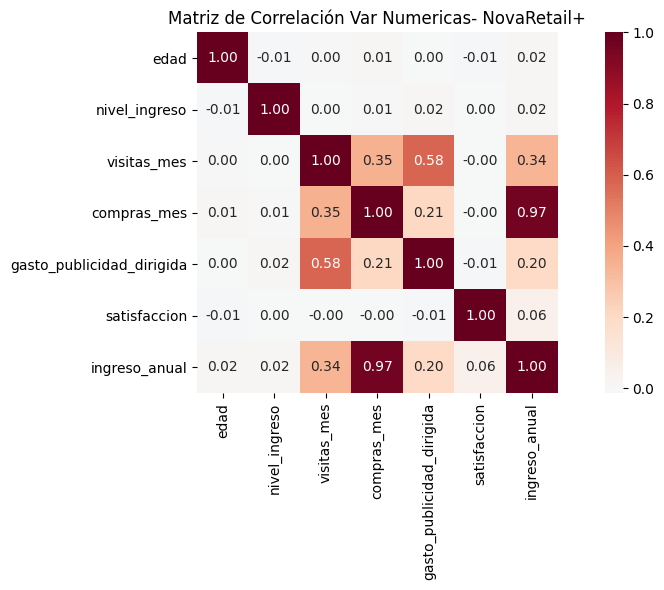

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones

#Matriz de Correlación
matriz_corr= df[columnas_numericas].corr()

#Heatmap
plt.figure(figsize=(10, 6))       # Tamaño
sns.heatmap(matriz_corr,          # Data
            annot=True,           # Mostrar números
            cmap='RdBu_r',        # Colores: rojo=positivo, azul=negativo
            center=0,             # Centro en 0
            square=True,          # Celdas cuadradas
            fmt='.2f')            # 2 decimales

plt.title('Matriz de Correlación Var Numericas- NovaRetail+')
plt.tight_layout()
plt.show()


**Observaciones generales (Heatmap)**

Se observa.
- Correlaciones fuertes — las dos señales dominantes:
    - La matriz está gobernada por dos relaciones de alta intensidad. `compras_mes` e `ingreso_anual` tienen una correlación de 0.97, prácticamente lineal — es la relación más fuerte de todo el heatmap.
    - La segunda señal fuerte es `visitas_mes` y `gasto_publicidad_dirigida` con 0.58, lo que sugiere que ambas variables se mueven en conjunto de forma consistente a lo largo de la base de usuarios.

- Un grupo de variables que se mueven juntas - Hay una agrupación o cluster de tres variables con correlaciones moderadas entre sí:
    - `visitas_mes`, `compras_mes` y `gasto_publicidad_dirigida`. Los valores 0.35, 0.58 y 0.21 dibujan un triángulo de comportamiento relacionado — usuarios con más visitas tienden a tener más compras y más exposición publicitaria. No es un bloque rígido, pero sí un patrón coherente de engagement.

- Relaciones débiles o irrelevantes
    - `edad` y `nivel_ingreso` son prácticamente independientes de todas las demás variables — ningún coeficiente supera 0.02 en valor absoluto. Son variables de perfil demográfico que, al menos en términos lineales, no explican el comportamiento transaccional ni el ingreso generado.
    - `satisfaccion` también se aísla completamente del resto, con correlaciones entre -0.01 y 0.06 — incluyendo con `ingreso_anual` (0.06), lo cual es contraintuitivo y merece una nota en el reporte.


Observaciones respecto a `ingreso_anual`  
- Presenta Tres lecturas ordenadas por relevancia:
   - La relación con `compras_mes` (0.97) es tan alta que invita a preguntarse si ingreso_anual se deriva parcialmente de compras_mes en la construcción del dataset — vale verificar que no sean variables redundantes o co-construidas antes del paso 4. Ingreso_anual puede ser el resultado de las compras_mes por el numero de meses del año (12).
   - La relación con `visitas_mes` (0.34) es moderada y esperada — más visitas se asocian con más ingreso, aunque la fuerza es mucho menor que la de compras, lo que sugiere que visitar sin comprar no genera valor económico relevante.
   - `Satisfaccion` correlaciona casi en cero con ingreso_anual (0.06). Esto es un hallazgo de negocio importante: los clientes que más ingresan no son necesariamente los más satisfechos — o la escala de satisfacción no captura lo que realmente impulsa el gasto.


### Scatterplot general

Generamos un *scatterplot* general.

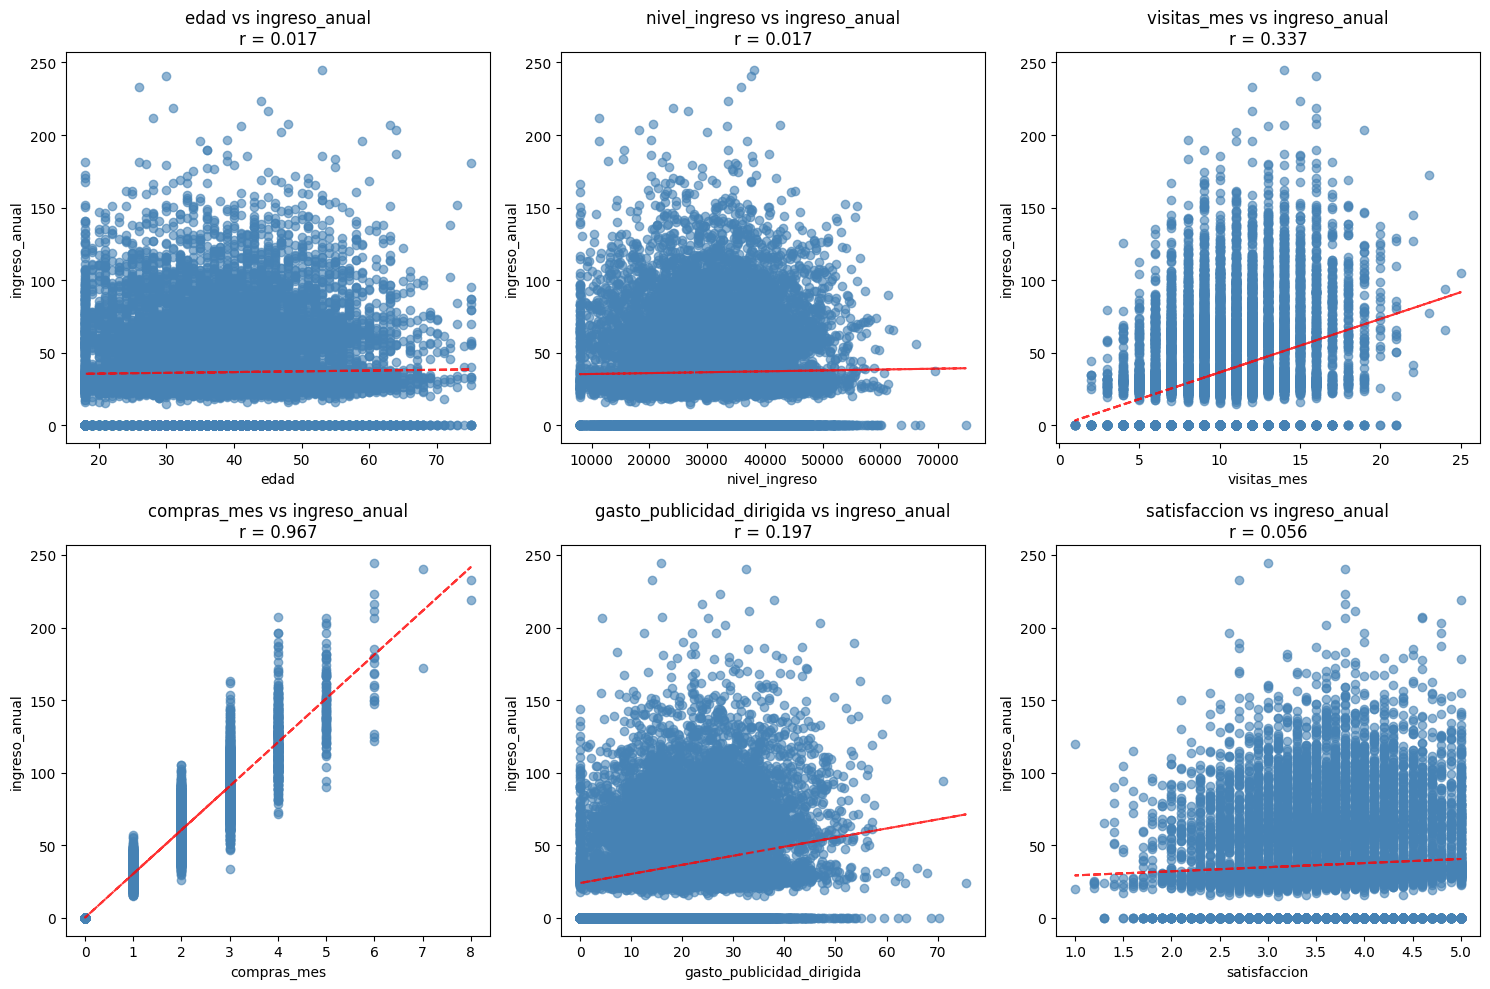

In [ ]:
# Variables numéricas
variables_numericas = ['edad', 'nivel_ingreso', 'visitas_mes',
                      'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion']

# Crear subplots y espacio para graficos de las variables
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

#Bucle que recorre variables vs. variable objetivo ingreso-anual
for i, var in enumerate(variables_numericas):
    #Scatterplot
    axes[i].scatter(df[var], df['ingreso_anual'], alpha=0.6, color='steelblue')

    #Etiquetas de los ejes
    axes[i].set_xlabel(var)                                                      # Etiqueta eje x
    axes[i].set_ylabel('ingreso_anual')                                          # Etiqueta eje y

    # Titulo y Mostrar correlación en el título
    corr_value = matriz_corr.loc[var, 'ingreso_anual']                           # Extraer Correlación
    axes[i].set_title(f'{var} vs ingreso_anual\nr = {corr_value:.3f}')           # Crear Titulo con Formato 3 decimales para correlacion

    # Línea de tendencia
    z = np.polyfit(df[var], df['ingreso_anual'], 1)                              # Coeficiente de Regresión
    p = np.poly1d(z)                                                             # Función polinómica
    axes[i].plot(df[var], p(df[var]), "r--", alpha=0.8)                          # Dibujar Línea de Tendencia

plt.tight_layout()                                                               # Espaciado y Orden
plt.show()                                                                       # Mostrar Grafico

**Descripción de patrones o tendencias observadas en Scatterplots vs ingreso_anual**

- `edad`:
    - Dirección: Positiva, Casi Nula,
    - Fuerza: Muy Debil,
    - Forma: Nube sin Patrón (Amorfa),
    - Dispersión: Muy Alta,
    - Tendencia: Plana,
    - La edad no discrimina el ingreso en ningún rango. Outliers dispersos en ingreso alto (>150) sin patrón etario. Variable descartable como predictor.
- `nivel_ingreso`:
    - Dirección: Positiva, Casi Nula,
    - Fuerza: Muy Debil,
    - Forma: Nube sin Patrón (Amorfa),
    - Dispersión: Muy Alta,
    - Tendencia: Plana,
    - El nivel de ingreso socioeconómico del cliente no predice lo que gasta en NovaRetail+. Hallazgo contraintuitivo para el reporte.
- `visitas_mes`:
    - Dirección: Positiva,
    - Fuerza: Moderada,
    - Forma: Lineal Discreta,
    - Dispersión: Alta,
    - Tendencia: Ascendente visible pero con enorme varianza dentro de cada nivel,
    - Franja densa en ingreso = 0 para todos los niveles de visitas — muchos visitantes no convierten. Relación real pero ruidosa.
- **`compras_mes`:**
    - Dirección: Positiva,
    - Fuerza: Muy Fuerte,
    - Forma: Lineal Escalonada,
    - Dispersión: Baja-Moderada,
    - Tendencia: Ascendente,
    - Outliers aislados en 6 compras con ingreso excepcionalmente alto (~240k). La línea de regresión sigue fielmente que cada nivel de compras le corresponde un rango de ingreso.
- `gasto_publicidad_dirigida`:
    - Dirección: Positiva leve,
    - Fuerza: Debil,
    - Forma: No Lineal, (Nube densa concentrada en gasto bajo (0–40))
    - Dispersión: Muy Alta,
    - Tendencia: Ascendente Muy leve,
    - A mayor gasto la dispersión aumenta y aparecen usuarios con ingreso = 0 pese a alta inversión publicitaria. Tendencia se diluye en gasto alto. Señal de ineficiencia en tramos altos.
- `satisfaccion`:
    - Dirección: Positiva casi Nula,
    - Fuerza: Muy Debil,
    - Forma: Sin Patrón,
    - Dispersión: Muy Alta,
    - Tendencia: Plana
    - En los niveles de satisfacción (2.0–5.0) existe el rango completo de ingresos, incluyendo cero. La línea de regresión es casi horizontal. Ausencia total de relación — resultado clave para el reporte.

El panel completo confirma una jerarquía muy clara. `compras_mes` es la única variable con una relación fuerte, lineal y visualmente evidente con `ingreso_anual` — el resto se separa por un abismo estadístico. El hallazgo más contraintuitivo y valioso para el reporte es el doble empate en r = 0.017 de `edad` y `nivel_ingreso`: dos variables de perfil demográfico que intuitivamente deberían importar, pero que en NovaRetail+ no explican nada del ingreso generado.

### Scatterplot para pares clave

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes ingreso_anual

# Obtener correlaciones con ingreso_anual
correlaciones = matriz_corr['ingreso_anual'].abs()

# Filtrar solo moderadas y fuertes (> 0.5)
correlaciones_significativas = correlaciones[correlaciones > 0.5]

# Excluir la variable consigo misma
correlaciones_significativas = correlaciones_significativas.drop('ingreso_anual')

print("Variables con correlación moderada/fuerte ingreso_anual:")
print(correlaciones_significativas.sort_values(ascending=False))

Variables con correlación moderada/fuerte ingreso_anual:
compras_mes    0.967149
Name: ingreso_anual, dtype: float64


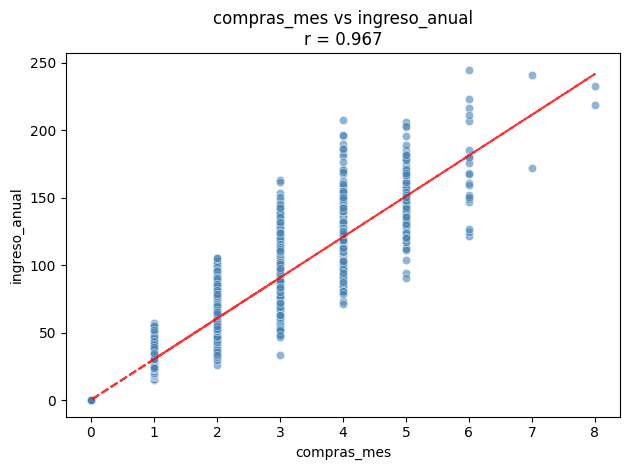

In [ ]:
# Scatter plot correlación fuerte compras_mes e ingreso_anual
sns.scatterplot(data= df, x= 'compras_mes', y = 'ingreso_anual', alpha=0.6, color='steelblue')

# Etiquetas y título
plt.xlabel('compras_mes')
plt.ylabel('ingreso_anual')

# Título que muestra correlación
corr_value = matriz_corr.loc['compras_mes', 'ingreso_anual']
plt.title(f'compras_mes vs ingreso_anual\nr = {corr_value:.3f}')

# Línea de tendencia
z = np.polyfit(df['compras_mes'], df['ingreso_anual'], 1)
p = np.poly1d(z)
plt.plot(df['compras_mes'], p(df['compras_mes']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes visitas_mes

# Obtener correlaciones con visitas_mes
correlaciones_visitas_mes = matriz_corr['visitas_mes'].abs()

# Filtrar solo moderadas y fuertes (> 0.5)
correlaciones_significativas_visitas_mes = correlaciones_visitas_mes[correlaciones_visitas_mes > 0.5]

# Excluir la variable consigo misma
correlaciones_significativas_visitas_mes = correlaciones_significativas_visitas_mes.drop('visitas_mes')

print("Variables con correlación moderada/fuerte visitas_mes:")
print(correlaciones_significativas_visitas_mes.sort_values(ascending=False))

Variables con correlación moderada/fuerte visitas_mes:
gasto_publicidad_dirigida    0.578947
Name: visitas_mes, dtype: float64


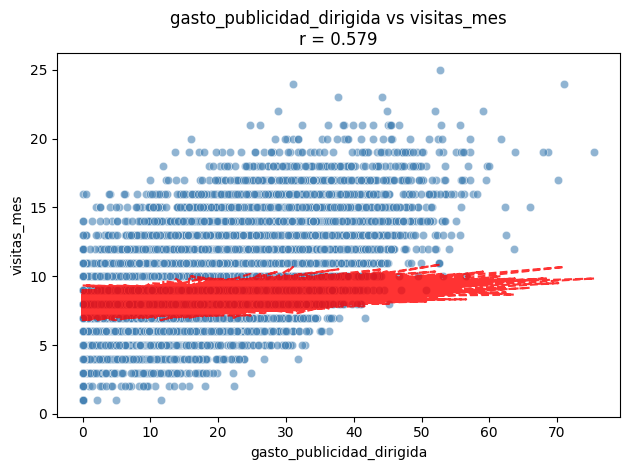

In [ ]:
# Scatter plot correlación moderada gasto_publicidad_dirigida y visitas_mes
sns.scatterplot(data= df, x= 'gasto_publicidad_dirigida', y = 'visitas_mes', alpha=0.6, color='steelblue')

# Etiquetas y título
plt.xlabel('gasto_publicidad_dirigida')
plt.ylabel('visitas_mes')

# Título que muestra correlación
corr_value = matriz_corr.loc['gasto_publicidad_dirigida', 'visitas_mes']
plt.title(f'gasto_publicidad_dirigida vs visitas_mes\nr = {corr_value:.3f}')

# Línea de tendencia
z = np.polyfit(df['gasto_publicidad_dirigida'], df['visitas_mes'], 1)
p = np.poly1d(z)
plt.plot(df['gasto_publicidad_dirigida'], p(df['visitas_mes']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

**Observaciones iniciales (Scatterplot) para pares claves:**

- **`compras_mes` vs `ingreso_anual`(r = 0.967):**
  
    - Dirección: Positiva,
    - Fuerza: Muy Fuerte,
    - Forma: Lineal Escalonada,
    - Colinealidad: severa, potencialmente redundancia conceptual.
    - Dispersión: Baja-Moderada,
    - Tendencia: Clara y consistentemente ascendente, la estructra sugiere que `ingreso_anual` se construye desde `compras_mes` — hay varianza dentro de cada nivel de compra pero no relevante para concluir que son variables independientes. Tendría que indagarse más para concluir esta sospecha.
          
- **`gasto_publicidad_dirigida` vs `visitas_mes` (r = 0.579):**
    - Dirección: Positiva,
    - Fuerza: Moderada-Alta,
    - Forma: No lineal, Nube con estructura rectangular,
    - Colinealidad: Sin colinealidad problemática, pero con solapamiento parcial.
    - Dispersión: Muy alta,
    - Tendencia: Difusa, no hay una progresión escalonada limpia,
    - Outliers: Algunos puntos aislados en visitas altas (>20) con gasto alto (>20). Y puntos con gasto muy alto (>65) pero visitas moderadas (~10–19).
    - **La inversión publicitaria mueve tráfico, pero ese tráfico no se traduce de forma confiable en valor económico(ingreso).**

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
# Comparar ambos métodos
pearson_corr = df.corr(method='pearson')
spearman_corr = df.corr(method='spearman')

# Ver diferencias para correlacion compras_mes vs ingreso_anual
print("Pearson vs Spearman para ingreso_anual:")
print(f"Compras_mes - Pearson: {pearson_corr.loc['compras_mes', 'ingreso_anual']:.3f}")
print(f"Compras_mes - Spearman: {spearman_corr.loc['compras_mes', 'ingreso_anual']:.3f}")

Pearson vs Spearman para ingreso_anual:
Compras_mes - Pearson: 0.967
Compras_mes - Spearman: 0.967


In [ ]:
# Calcular correlación entre variables relevantes

# Ver diferencias para correlacion visitas_mes vs ingreso_anual
print("Pearson vs Spearman para ingreso_anual:")
print(f"Visitas_mes - Pearson: {pearson_corr.loc['visitas_mes', 'ingreso_anual']:.3f}")
print(f"Visitas_mes - Spearman: {spearman_corr.loc['visitas_mes', 'ingreso_anual']:.3f}")

Pearson vs Spearman para ingreso_anual:
Visitas_mes - Pearson: 0.337
Visitas_mes - Spearman: 0.321


In [ ]:
# Calcular correlación entre variables relevantes

# Ver diferencias para correlacion gasto_publicidad_dirigida vs ingreso_anual
print("Pearson vs Spearman para ingreso_anual:")
print(f"gasto_publicidad_dirigida - Pearson: {pearson_corr.loc['gasto_publicidad_dirigida', 'ingreso_anual']:.3f}")
print(f"gasto_publicidad_dirigida - Spearman: {spearman_corr.loc['gasto_publicidad_dirigida', 'ingreso_anual']:.3f}")

Pearson vs Spearman para ingreso_anual:
gasto_publicidad_dirigida - Pearson: 0.197
gasto_publicidad_dirigida - Spearman: 0.185


**Observaciones de la comparación de ceficientes de correlación (Pearson vs Spearman)**

- **`compras_mes` vs `ingreso_anual`**:
    - Correlación Adecuada: Pearson (r = 0.967), correlacion lineal;  
    - Distribución normal y relación lineal, sin distorsion por Outliers al compararla con Spearman;
    - Dirección: Positiva;
    - Magnitud: Muy Fuerte 0.967 (>0.8);
    - Colinealidad: Severa, Fuertemente correlacionadas entre sí (>0.8)
    - Variables que pueden estar proporcionando información redundante - miden prácticamente lo mismo.

- **`visitas_mes` vs `ingreso_anual`**:
    - Correlación Adecuada: Spearman (r =0.321), correlación monotonica;
    - Dirección: Positiva;
    - Magnitud: Moderada-Baja (<0.5)
    - Colinealidad: Sin riesgo
    - Spearman es el coeficiente más honesto y confiable aquí, dado que ingreso_anual tiene distribución asimétrica con P25 = 0 (Sesgo).
      

- **`gasto_publicidad_dirigida` vs `ingreso_anual`**:
    - Correlación  Adecuada: Spearman (r =0.185), correlación monotonica;
    - Dirección: Positiva muy leve;
    - Magnitud: Debil (<0.3);
    - Colinealidad: Sin riesgo
    - Spearman al igual que en la anterior correlacion, es el coeficiente más honesto y confiable, dado que ingreso_anual tiene distribución asimétrica con P25 = 0 (Sesgo).
  


### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes

from scipy.stats import pointbiserialr

# Lista de variables binarias a evaluar
variables_binarias = ['miembro_premium', 'abandono']

# Diccionario para almacenar resultados
resultados_punto_biserial = {}

# Bucle para calcular correlaciones punto biserial
for variable in variables_binarias:
    corr, p_value = pointbiserialr(df[variable], df['ingreso_anual'])

    # Guardar resultados en el diccionario
    resultados_punto_biserial[variable] = {
        'correlacion': corr,
        'p_value': p_value,
        'significativa': p_value < 0.05
    }

    # Mostrar resultados inmediatamente
    print(f"\n {variable} vs ingreso_anual:")
    print(f"   Correlación: {corr:.4f}")
    print(f"   P-value: {p_value:.4f}")


 miembro_premium vs ingreso_anual:
   Correlación: 0.0931
   P-value: 0.0000

 abandono vs ingreso_anual:
   Correlación: -0.0028
   P-value: 0.7295


**Observaciones, Diagnostico Punto-biserial:**

**`miembro_premium` vs `ingreso_anual`** (r = 0.0931)
- Relación casi Nula (<0.10);
- Dirección: Ligeramente Positiva;
- Magnitud: Muy baja;
- La membresía no es un discriminador potente del valor económico del cliente en este dataset

**`abandono` vs `ingreso_anual`** (r = -0.003)
- Relación Nula (<0.00), no hay relacion;
- Dirección: Negativa;
- Magnitud: Nula;
- Los clientes que abandonan no son distinguibles por su ingreso anual de los que se quedan.

### V de Cramér

In [ ]:
# Función para calcular V de Cramér

from scipy.stats import chi2_contingency

def cramer_v(df, col1, col2):
    # tabla de contingencia
    tabla = pd.crosstab(df[col1], df[col2])

    # calcular chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(tabla)

    # calcular coeficiente V de Cramér
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))

    return v

In [ ]:
# Aplicar V de Cramér en variables relevantes
resultado_cramer = cramer_v(df,"region","tipo_dispositivo")
print(f'Coeficiente V de Cramer Region vs Tipo Dispositivo')
print(f"   Correlación: {resultado_cramer:.4f}")

Coeficiente V de Cramer Region vs Tipo Dispositivo
   Correlación: 0.0124


**Observaciones V de Cramér:**

- **Region vs Tipo Dispositivo V de Cramér = 0.0124**

    - Asociación prácticamente nula entre las dos variables categóricas, relación debil, no hay relacion (<0.10)
    - Coeficiente V de Cramér oscila entre 0 (independencia total) y 1 (asociación perfecta). Un valor de 0.0124 está tan cerca de cero que, para efectos prácticos, region y tipo_dispositivo son independientes entre sí
    - La distribución de dispositivos usados es casi idéntica en las cuatro regiones — norte, sur, este y oeste tienen proporciones de móvil, escritorio y tablet prácticamente iguales.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  incluye:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — Compras_mes es el factor más fuertemente asociado con el ingreso_anual generado

**Evidencia visual:** Scatterplot compras_mes vs ingreso_anual y Heatmap.

**Evidencia numérica:** Pearson = 0.967 · Spearman = 0.967

**Interpretación**
A mayor número de compras en el mes, el ingreso anual generado por el cliente tiende a ser consistentemente más alto. Asociación más Fuerte de todas las variables analizadas.


**No podemos afirmar**
Que comprar más causa mayor ingreso anual. Una correlación de 0.967 es inusualmente alta y podría indicar que ambas variables comparten una causa subyacente común — por ejemplo, un perfil de cliente de alto valor que naturalmente compra más y genera más ingreso — o que ingreso_anual fue construido parcialmente a partir de compras_mes en el proceso de generación del dataset.  


**Implicación de negocio**
Priorizar estrategias que incrementen la frecuencia de compra — programas de recompensa, recomendaciones personalizadas, reducción de fricción en el proceso de pago — con la hipótesis de que aumentar compras_mes estaría asociado con incremento en ingreso_anual. Iniciativas que deben ser validadas mediante experimentos controlados.


### Hallazgo 2 — visitas_mes tiene una asociación moderada con el ingreso_anual, pero la conversión es el eslabón crítico

**Evidencia visual:** Scatterplot visitas_mes vs ingreso_anual y Heatmap.  
**Evidencia numérica:** Spearman = 0.321

**Interpretación**  
Los clientes que visitan más la plataforma tienden a generar más ingreso. Sin embargo, la relación es ruidosa y la franja de ingreso cero para usuarios con alta frecuencia de visitas revela que visitar la plataforma no es suficiente para generar valor económico.

**No podemos afirmar**  
Que incrementar las visitas produce mayor ingreso. La causalidad inversa es igualmente plausible: los clientes de mayor valor visitan más porque tienen mayor intención de compra de base.

**Implicación de negocio**  
Analizar qué diferencia a los visitantes frecuentes que compran de los que no lo hacen podría revelar palancas accionables — experiencia de usuario, barreras de pago, relevancia del catálogo — sin necesidad de atraer nuevo tráfico.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad

Que compras_mes tenga r = 0.967 con ingreso_anual no permite afirmar que comprar más produce mayor ingreso. La dirección de la relación y la existencia de variables confusoras no pueden determinarse con un análisis correlacional.
Que visitas_mes se asocie moderadamente con ingreso_anual (Spearman = 0.321) no implica que aumentar visitas incremente el ingreso — la intención de compra previa del cliente podría explicar ambas variables simultáneamente.

- Posible redundancia entre variables

La coincidencia exacta Pearson = Spearman = 0.967 entre compras_mes e ingreso_anual genera la sospecha de que ambas variables podrían ser co-construidas en el dataset. Si ingreso_anual se calculó a partir de compras_mes y un ticket promedio, no son variables independientes. Esto debe verificarse con el diccionario de datos antes de cualquier modelado predictivo.

- Variables de comportamiento no medidas

El dataset no captura variables que podrían explicar por qué algunos usuarios visitan frecuentemente sin comprar: tiempo en sesión, categorías navegadas, productos añadidos al carrito sin completar la compra, historial de devoluciones o exposición a descuentos. La conversión — el eslabón crítico entre visitas e ingreso — no tiene una variable directa en el dataset.

- Distribución asimétrica de la variable objetivo

ingreso_anual tiene P25 = 0, lo que indica que al menos el 25% de los usuarios no genera ingreso registrado. Esta masa de ceros influye en todos los coeficientes calculados y puede estar enmascarando patrones distintos entre el segmento activo y el segmento sin conversión. Los análisis realizados describen la población completa, no segmentos diferenciados.

Alcance temporal

- El análisis cubre un corte transversal de 2024. No es posible determinar si las asociaciones observadas son estables en el tiempo, estacionales o producto de condiciones específicas del período analizado.

### **Próximos pasos**

- Verificar la independencia de compras_mes e ingreso_anual

Consultar el diccionario de datos para confirmar si ingreso_anual se construyó a partir de compras_mes. Si son variables dependientes, compras_mes debe excluirse como predictor en modelos futuros de ingreso_anual.

- Segmentación por conversión

Separar la base en dos subpoblaciones: usuarios con compras_mes = 0 (sin conversión) y usuarios con compras_mes ≥ 1 (con conversión). Repetir el análisis correlacional en cada segmento por separado para identificar si los drivers de ingreso difieren entre grupos.
Analizar el perfil de usuarios con alta frecuencia de visita (visitas_mes ≥ 15) y compras_mes = 0 — este segmento representa una oportunidad de conversión no capturada y podría tener características distintivas accionables.

- Análisis de cohortes temporales

Si el dataset puede enriquecerse con una dimensión de tiempo, construir cohortes mensuales para evaluar si el aumento de visitas precede al aumento de compras en el tiempo — lo que aportaría evidencia indirecta sobre la dirección de la relación, sin establecer causalidad formal.

- Experimento controlado sobre frecuencia de visitas

Diseñar un experimento A/B que incremente artificialmente las visitas de un grupo de usuarios mediante notificaciones o incentivos, manteniendo un grupo control sin intervención. Medir si el grupo tratado incrementa compras_mes e ingreso_anual de forma diferencial. Este sería el primer paso hacia evidencia causal sobre la relación visitas_mes → ingreso.

- Incorporar variables de comportamiento no medidas

Enriquecer el dataset con métricas de sesión (tiempo en plataforma, tasa de abandono de carrito, categorías visitadas) para identificar qué diferencia a los visitantes que convierten de los que no lo hacen. Esto permitiría construir un score de propensión a la compra más robusto que visitas_mes como predictor aislado.

- Modelo predictivo de ingreso_anual

Una vez verificada la independencia conceptual de las variables, construir un modelo de regresión con las variables de comportamiento como predictores (visitas_mes, gasto_publicidad_dirigida, miembro_premium) excluyendo compras_mes si se confirma redundancia. Evaluar con métricas robustas a la asimetría de la distribución objetivo (MAE, RMSE sobre escala logarítmica).